# COMP9444 Group Project: Neural Networks & Deep Learning: NLP Classification of FOMC Texts for Market Analysis

Authors:
Ying Bi (z5444398), Wing Pui (Nigel) Li (z5320405), Zhenhua Liu (z5433153), Tong Zhang (z5542524)

## 1. Introduction, Motivation, and Problem Statement
### 1.1 Introduction/Problem Statement

Central Bank communication, especially FOMC statements have historically had a significant impact of global financial markets. Stakeholders ranging from investors, policymakers, and even the layman, closely observe these announcements to make informed decisions that are appropriate. Correa et al. (2020) found that sentiment scores are a useful predictive tool for banking crises finding a that a 1% increase in negative sentiment is assocaited with 29% increases in crises, while Hilscher et al. (2024) showcased the potential usage of sentiment as a forward indicator for monetary policy. Notwithstanding, there are numerous other potential usages for the accurate outputs of sentiment analysis.


Despite such the numerous applications of sentiment scores, attempts by numerous academics and scientists have historically struggled to capture the nuance of language within such statements. Traditional sentiment analysis, using tools like LSTM, have failed to fully encompass the complexities inherent in policy communication, and has led to suboptimal outcomes. This, is this a **major problem** that is to be resolved for stakeholders, and contemporary state-of-the-art NLP models might offer an answer.



### 1.2 Purpose

The primary purpose of this project is to develop a **"best practice"** NLP model that successfully bridge the gap between traditional sentiment analysis tools in classifying FOMC texts into Neutral, Hawkish, or Dovish sentiments, and seek to evaluate whether such models are suitable for industry, and, or stakeholder usage. It aims to experiment and fine-tune current state-of-the-art NLP models and techniques, including LSTM, BERT, RoBERTa, DeBERTa, and Qwen.  By doing so, the "best practice" is developed through improvements of existing models, and providing valuable insights for stakeholders in policy analysis, economic forecasting and financial market decision making.

The models will be designed to categorise the text into three specific categories: Neutral, Hawkish, or Dovish (or {0, 1, 2}). We aim to achieve this, by evaluating, and experimenting with transformer-based models, whilst using the traditional LSTM framework as a "foundation", which we seek to expand upon. As detailed below, we first seek to establish a "baseline" through a relatively fine-tuned LSTM, and then proceed to train our models individually. Following this, the most promising models are selected, and hyperparameter-optimised via a two stage process (random to find more promising areas, then more tailored search) in order to save on computation. We select the best-performing model by comparing the three evaluation metrics: accuracy, precision, and F1-score. Finally to develop a best practice, Etelis et al. (2024) did note that stacking can improve the ability for NLP models to generalise, for sentiment analysis, and choosing our best performing models - we attempted to develop such meta-models, and evaluted its performance.

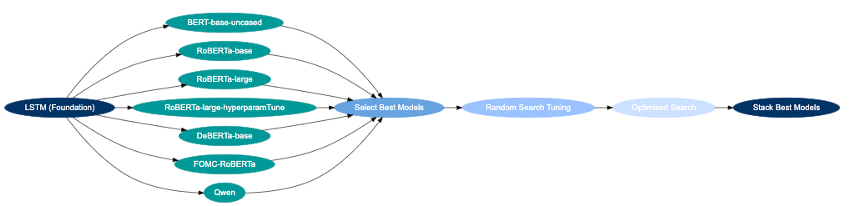




## 2. Data Sources or Reinforcement Learning Tasks

The dataset used from this project from the Financial Services Innovation Lab at Georgia Tech, as prescribed be the assessment guidelines. The dataset includes FOMC meeting text data spanning from 1996 to 2022, comprising of transcripts from meetings, press conferences, and speeches delivered by Federal Reserve officials, combined with semantic labels indicating their policy stance. The repository includes multiple training and validation datasets, wherein the “5768” dataset because of its balance between computational feasibility and class distribution. Other datasets, were much larger in sizes, and with less equal distribution. The dataset is structured with the following columns: 'index', 'sentence', 'year', and 'label'."

The link is available here:

https://github.com/gtfintechlab/fomc-hawkish-dovish/tree/main/training_data/test-and-training


Data Source:

* Dataset: 5768 Dataset
* Created by Financial Services Innovation Lab at Georgia Tech
* Training & Validation Set, with four columns, {index, sentence, year, label}, the dependent variable is the label, and the independent variable is the sentence. 
* Label is a number of {0,1,2} representing sentiment, and is an **int**, whereas sentence are **string**s 

S/s of the given training data (5768):


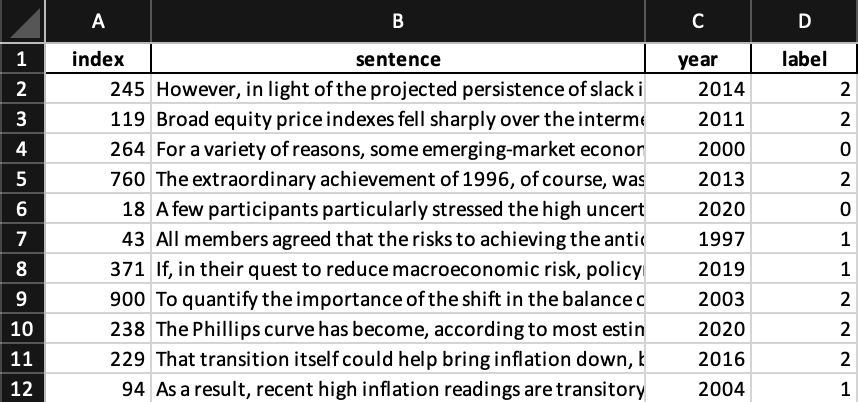


## 3. Exploratory Analysis of Data

Notable characteristic of the data:

* Dataset is categorised into three classes, Neutral, Hawkish, and Dovish, corresponding to labels {0, 1, 2}, respectively

* Distribution across the dataset maintains about a 2:1:1 split across th three classes, which provides a relatively balanced view to train and test sentiment across different stances. Attempts to rebalance were considered. This is showcased below as a bar chart.

* Training and Testing split, was 80/20 split. This was relatively more balanced compared to other training sets.

* Token Length Analysis was conducted, with a majority of sentences in the dataset contain fewer than 50 tokens, with a peak between 20-30 tokens. This directly contributes to choice of token limits later.


The Pre-processing steps taken to prepare the data are different for LSTMs, and for BERT variations. 

* **Tokensiation** - Word2Vec for LSTM to convert words into continuous vector representations

* **Subword Tokensiation** - For transformer models, to handle rare words that help a breakdown into smaller and more understandable units.



Notably, in data pre-processing stage, researchers applied dictionary filters to identify and retain key sentences, ensuring that the data is relevant to changes in the stance of monetary policy.The annotation of this data set was completed by two independent annotators to ensure annotation consistency. The data itself waas cleaned already, and our pre-processing stage only involved tokenisation.


## *Challenges Encountered*
A notable challenge encountered was data imbalance. We intiially utilised a Weighted Loss function, assigning different weights to different classes based on frequency. The idea of this was that it will pay more attnetion to minority classes (1, 2), and penalise errors. This was not successful, as the evaluation metrics all declined precipitously.

We considered also using SMOTE after reading : 

(https://ruslanmv.com/blog/How-to-handle-imbalanced-text-data-in-Natural-Language-Processing?srsltid=AfmBOoocTFqTzp0Pj3K2hj0PWoeTpqo2NcQyAlQulzMihvMvXcSuh4VT),

 but SMOTE was not effective.Some reaasearch was done, and it appears that SMOTe is not effective for textual data, as we used word vectorssentence embeddings - and interpolating between such embeddings to crete artifical samples can result in vectors of dubious quality. As a result, it can lead to data that does not make sense, therefore worsening our performance - which it did

Further research was done, and some have argued that data imabalances aren't that major of an issue:
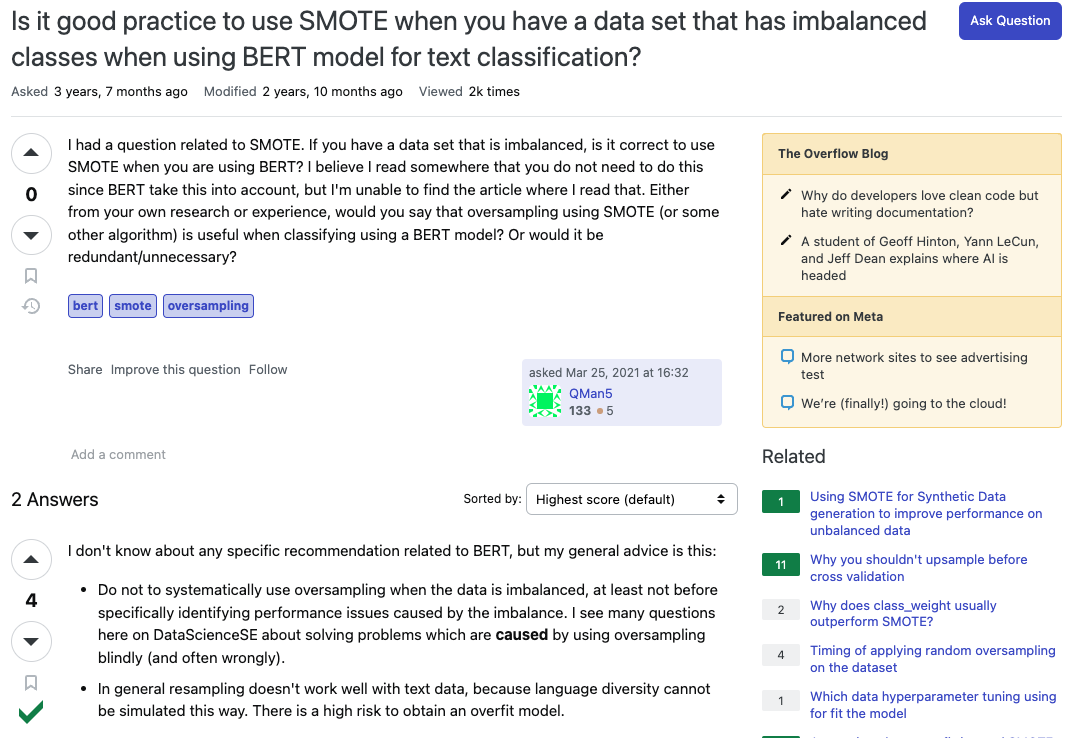

Source: (https://datascience.stackexchange.com/questions/91141/is-it-good-practice-to-use-smote-when-you-have-a-data-set-that-has-imbalanced-cl)


### 3.1 Load data from csv file
The provided dataset has already been split into an 80:20 ratio for the training and test sets based on FOMC financial session data. In the data exploration section, we focus on "exploring" the data presented.

[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/zhangtong/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /Users/zhangtong/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     /Users/zhangtong/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     /Users/zhangtong/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     /Users/zhangtong/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


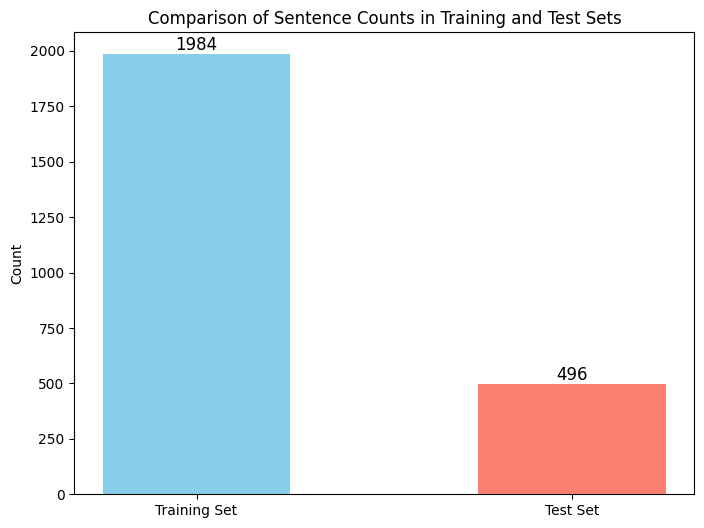

In [26]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import nltk
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('wordnet')
nltk.download('omw-1.4')
nltk.download('punkt_tab')
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
import string
train_df = pd.read_excel('ipynb_projects/dataset/lab-manual-split-combine-train-5768.xlsx')
test_df = pd.read_excel('ipynb_projects/dataset/lab-manual-split-combine-test-5768.xlsx')

total_df = pd.concat([train_df,test_df],axis=0)
df = total_df[['sentence','label']]
train_count = train_df['sentence'].count()
test_count = test_df['sentence'].count()

plt.figure(figsize=(8, 6))
bars = plt.bar(['Training Set', 'Test Set'], [train_count, test_count], color=['skyblue', 'salmon'], width=0.5)

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, yval, int(yval), ha='center', va='bottom', fontsize=12)

plt.ylabel('Count')
plt.title('Comparison of Sentence Counts in Training and Test Sets')
plt.show()

The above visualisation re-afffirms the point of an 80/20 split in the data, and the dataset is sufficiently large enough for good training, but not too large, as it may become too computationally expensive

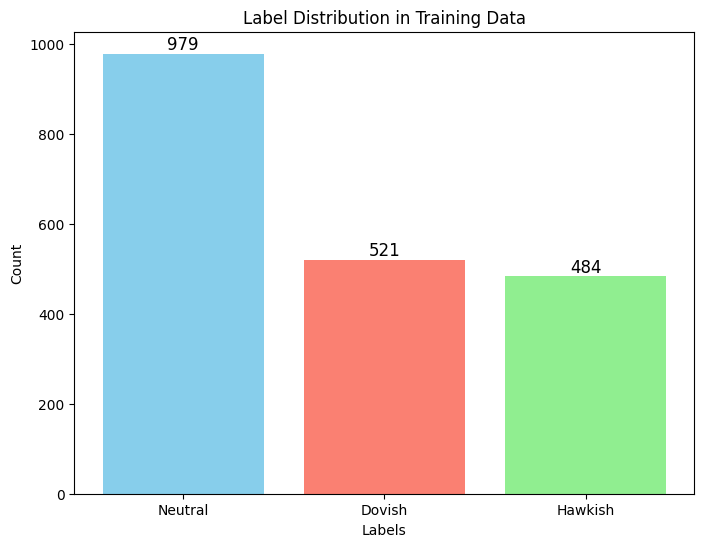

In [27]:
label_counts = train_df['label'].value_counts()

dic_label={
    0:'Dovish',
    1:'Hawkish',
    2:'Neutral',
}

train_df['label_name'] = train_df['label'].map(dic_label)

label_counts = train_df['label_name'].value_counts()

plt.figure(figsize=(8, 6))
bars = plt.bar(label_counts.index, label_counts.values, color=['skyblue', 'salmon', 'lightgreen'])

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, yval, int(yval), ha='center', va='bottom', fontsize=12)

plt.xlabel('Labels')
plt.ylabel('Count')
plt.title('Label Distribution in Training Data')
plt.show()

The above visualisation does show Neutral as the most dominant class with approximately a 2:1:1 ratio, but aas a result of the natural language input data, traidtional rebalancing techniques are insufficient.

### 3.2 Pre-processing of NLP data（LSTM）
#### 3.2.1 Sentence to word list，and unify capitalisation and remove punctuation

Conducted to facilitate tokensation, and analyse words on a word-level rather than entire sentence. On the other hand, it helps creating a structured representation of the data. Converting all words to lower case help avoiding duplicate reprsentations fo the same word. Removal of punctuation helps in simplifying the data, making it easier to focus on meaningful words w/o distraction of unnecessary information.

In [28]:
def clean_text(text):
    lemmatizer = WordNetLemmatizer()
    stop_words = set(stopwords.words('english'))
    text = text.lower()
    text = ''.join([char for char in text if char not in string.punctuation])
    words = word_tokenize(text)
    cleaned_words = [lemmatizer.lemmatize(word) for word in words]
    
    return cleaned_words


In [29]:
train_sentences = train_df['sentence'].apply(lambda x: clean_text(x))
print('Original sentence data:', train_df['sentence'][0])
print('Sentence to word list:',train_sentences[0])

Original sentence data: Our mandate, sorry, is price inflation.
Sentence to word list: ['our', 'mandate', 'sorry', 'is', 'price', 'inflation']


#### 3.2.2 Observe the distribution of sentence length

The purpose of this exercise is to look ath the lengths, and by extension, guide our choice of token limits during data pre-processing. By extension, this guides the pre-processing steps we seek to take.

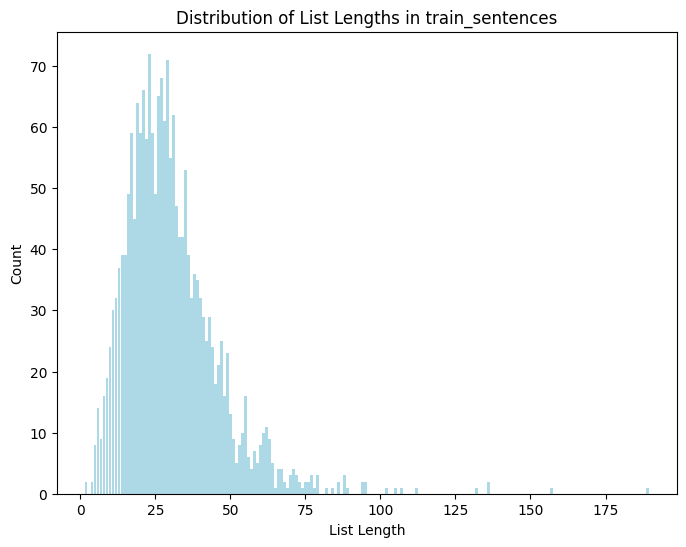

In [30]:
lengths = train_sentences.apply(len)

length_counts = lengths.value_counts().sort_index()
plt.figure(figsize=(8, 6))
plt.bar(length_counts.index, length_counts.values, color='lightblue')

plt.xlabel('List Length')
plt.ylabel('Count')
plt.title('Distribution of List Lengths in train_sentences')
plt.show()


#### 3.2.3 Word to Vector (Embedding)
In the LSTM model, each word in the training set is initially converted into a word vector with a dimension of 75, where each component of the word vector represents a value on a specific abstract dimension.

In [31]:
import gensim
from gensim.models import Word2Vec
vector_size = 75
word2vec_model = Word2Vec(sentences=train_sentences, vector_size=vector_size, window=5, min_count=1, workers=4)

print(word2vec_model.wv['inflation'])  

[-0.03062684  0.08955467 -0.093592   -0.4331314  -0.18476471 -0.23391557
 -0.50237346  0.36332834  0.79960805 -0.36875832  0.97034854  0.02485276
 -0.17181824  1.0688424  -0.65687793  0.41233587 -0.28514865  0.16043174
  0.13698532  1.1824657  -0.22443391  0.10674047  0.07091632  0.55270827
  0.44431946 -0.2735167  -0.541683    0.19505592  0.05287177 -1.2524678
 -0.9012584   0.46769074  0.3516178  -1.4058145  -1.0549835  -0.3166435
  0.8806756   0.46073642 -0.44495258 -0.77582633  0.40043417  0.9248946
  0.2424578  -1.1149615  -0.07055514  0.01238261  0.11253965  1.1464703
 -0.15567006  0.59703285  0.23529035  0.17955063 -0.61918586 -1.0891014
  1.1566877   0.547092    0.52013695  0.4062862  -1.2898786   0.06620084
 -0.16571443 -1.2857704   0.04972851 -0.34733963  0.35489348  0.07911522
 -0.47579005 -0.16758268 -0.49236912  0.3767399   0.9571146   0.23802446
 -0.03100981  0.00965107 -0.4071859 ]


In [32]:
def sentence_to_embedding(sentence, model, vector_size):
    embedding = []
    for word in sentence:
        if word in model.wv:
            embedding.append(model.wv[word])
        else:
            embedding.append(np.zeros(vector_size))  
    return np.array(embedding)

train_embeddings = train_sentences.apply(lambda x: sentence_to_embedding(x, word2vec_model, vector_size))

print(train_embeddings.head())

0    [[-0.026578436, 0.08436462, -0.08369971, -0.43...
1    [[-0.008507154, 0.026780978, -0.023391262, -0....
2    [[-0.03701356, 0.063869886, -0.05497405, -0.49...
3    [[-0.019244011, 0.022987368, -0.033033744, -0....
4    [[-0.03701356, 0.063869886, -0.05497405, -0.49...
Name: sentence, dtype: object


The custom dataset ensures a one-to-one correspondence between embeddings and labels and limits sentence length. Zero vectors are used for padding to extend sentences to a uniform length, preparing the data for the subsequent model.

In [33]:
from torch.utils.data import Dataset, DataLoader

class Word2VecDataset(Dataset):
    def __init__(self, embeddings, labels, max_len):
        self.embeddings = embeddings
        self.labels = labels
        self.max_len = max_len

    def __len__(self):
        return len(self.embeddings)

    def __getitem__(self, index):
        embedding = self.embeddings[index]
        label = self.labels[index]

        if len(embedding) < self.max_len:
            padding = np.zeros((self.max_len - len(embedding), embedding.shape[1]))
            embedding = np.vstack((embedding, padding))
        elif len(embedding) > self.max_len:
            embedding = embedding[:self.max_len]

        return {
            'embedding': torch.tensor(embedding, dtype=torch.float32),
            'label': torch.tensor(label, dtype=torch.long)
        }

max_len = 50

train_dataset = Word2VecDataset(train_embeddings, train_df['label'].values, max_len)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)


### 3.3 re-processing of NLP data（Transformer pre-train model（Encoding））
- When using a transformer pre-trained model, we first import the tokenizer of the language model to perform word embedding.
- A data loader is defined to map the training sentences using the imported tokenizer. Each word in the sentence is mapped to an ID, which can then index the word embedding vector in the transformer.

In [34]:
import torch
from transformers import BertTokenizer, BertForSequenceClassification

tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")

class BertDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, index):
        text = self.texts[index]
        label = self.labels[index]
        
        encoding = self.tokenizer(
            text,
            padding='max_length',
            truncation=True,
            max_length=self.max_len,
            return_tensors='pt'
        )

        return {
            'input_ids': encoding['input_ids'].squeeze(),
            'attention_mask': encoding['attention_mask'].squeeze(),
            'labels': torch.tensor(label, dtype=torch.long)
        }


max_len = 75
train_dataset = BertDataset(train_df['sentence'].tolist(), train_df['label'].values,tokenizer,max_len)

# DataLoader
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=False)

first_batch = next(iter(train_loader))
print('Original Sentence:',train_df['sentence'][1])
print('input id of Sentence:',first_batch['input_ids'][1])


Original Sentence: During the past several years, workers across the wage distribution--not just at the upper end--have seen noticeable increases in the inflation-adjusted value of their wages.
input id of Sentence: tensor([  101,  2076,  1996,  2627,  2195,  2086,  1010,  3667,  2408,  1996,
        11897,  4353,  1011,  1011,  2025,  2074,  2012,  1996,  3356,  2203,
         1011,  1011,  2031,  2464, 17725,  7457,  1999,  1996, 14200,  1011,
        10426,  3643,  1997,  2037, 12678,  1012,   102,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0])


/Users/zhangtong/anaconda3/envs/nlp-9444/lib/python3.10/site-packages/transformers/tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(


In [35]:
begin_token = tokenizer.convert_ids_to_tokens(101)
end_token = tokenizer.convert_ids_to_tokens(102)
print('Begin token:',begin_token)
print('End token:',end_token)

Begin token: [CLS]
End token: [SEP]


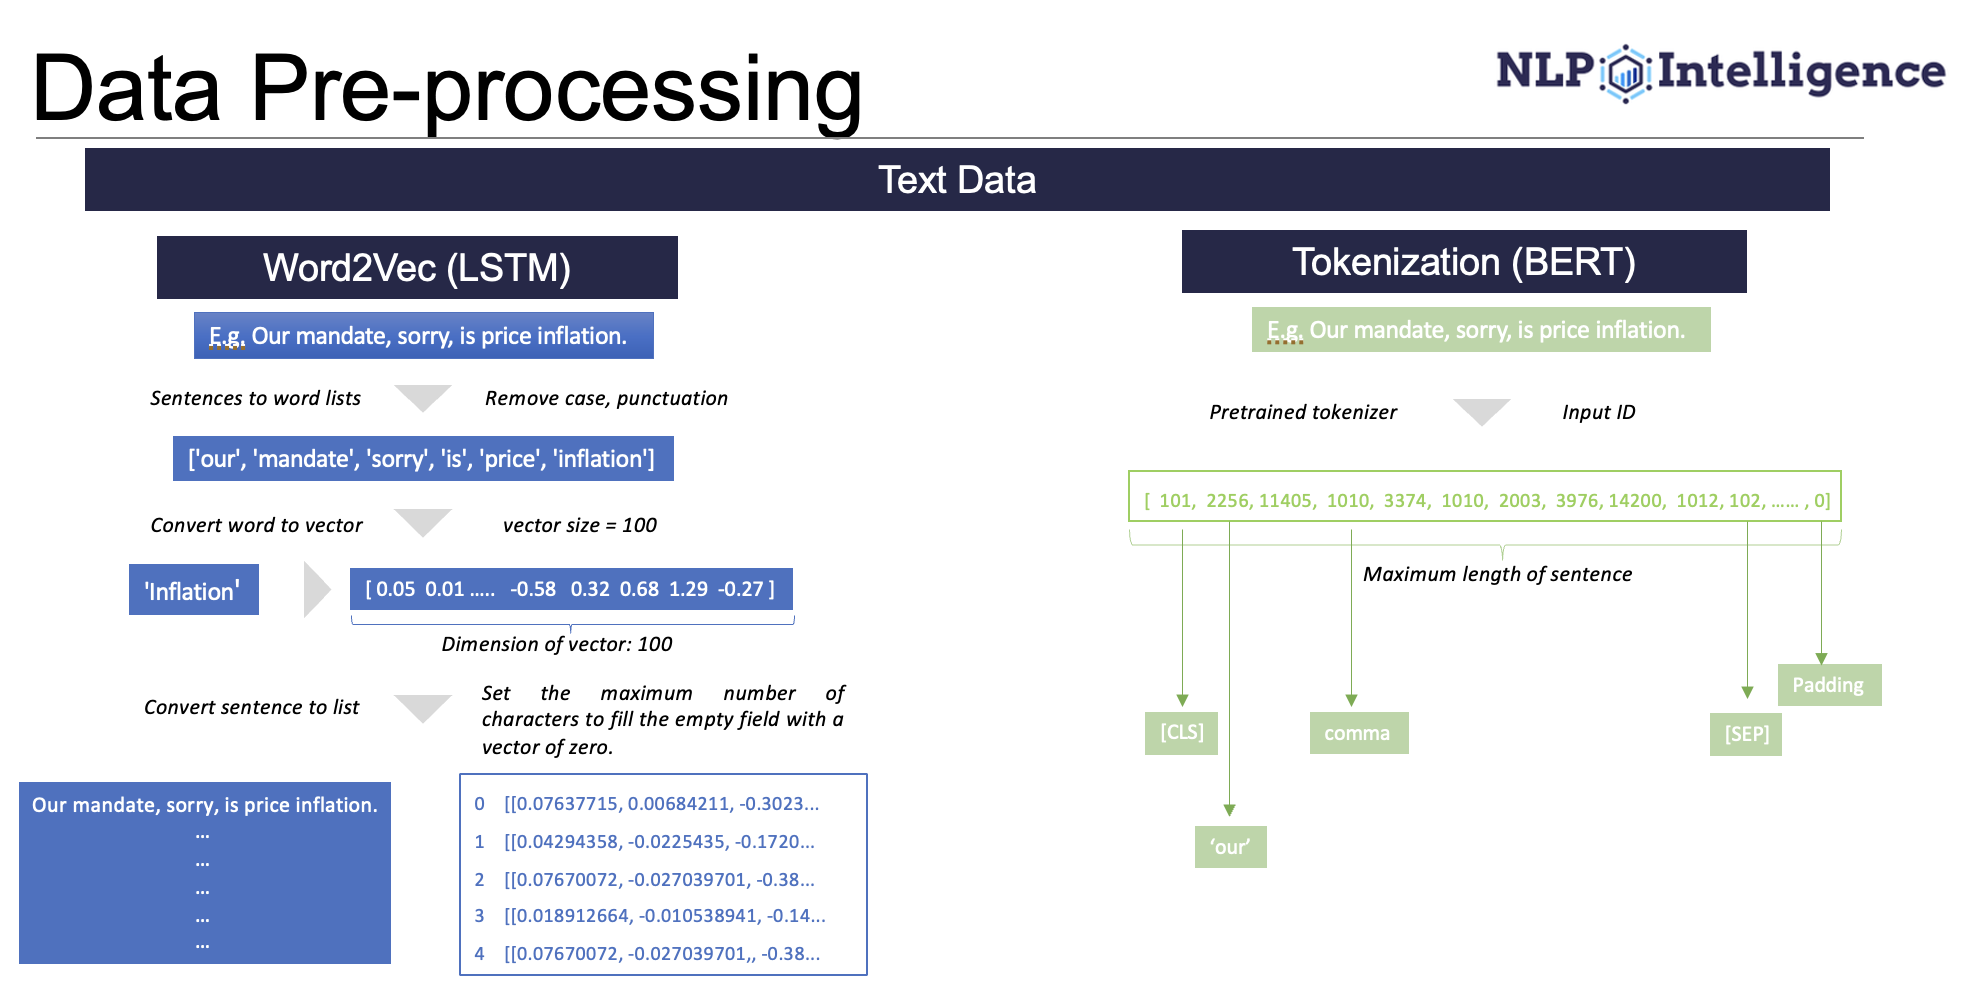  

The data-preprocessing process was detailed as above, to showcase how the process works for LSTM & BERT variations. We produced this visualisation on PowerPoint, and it was presented on Tuesday.

## 4. Models

In order to compare the different outcomes from various models, we have train and test 8 models. Here is the list in the table below, including the corresponding .pth files and the referenced Jupyter notebooks as well as the name who finish the notebook. Please refer to the actual models provided in the directory containing the relevant .ipynb files.

All the models were chosen based off the literature review we had conducted. As shown, the models were generally chosen, based off what other researchers had done, especially for LSTM as an RNN framework, and pre-trained transformer frameworks of the BERT family. We attempted, and in most cases beat the relevant baseline models. For example Araci (2019) posited finBERT that yielded ~ 80ish% accuracy, our fine-tuned model yielded 93% at the end. Literature suggested average accuracy of a stacked model, with 90% + accuracy in Etelis et al. (2023) formed as the basis of our stacking attempts from the selection of the best models we had. Refer to the timeline of papers we had referred to. 

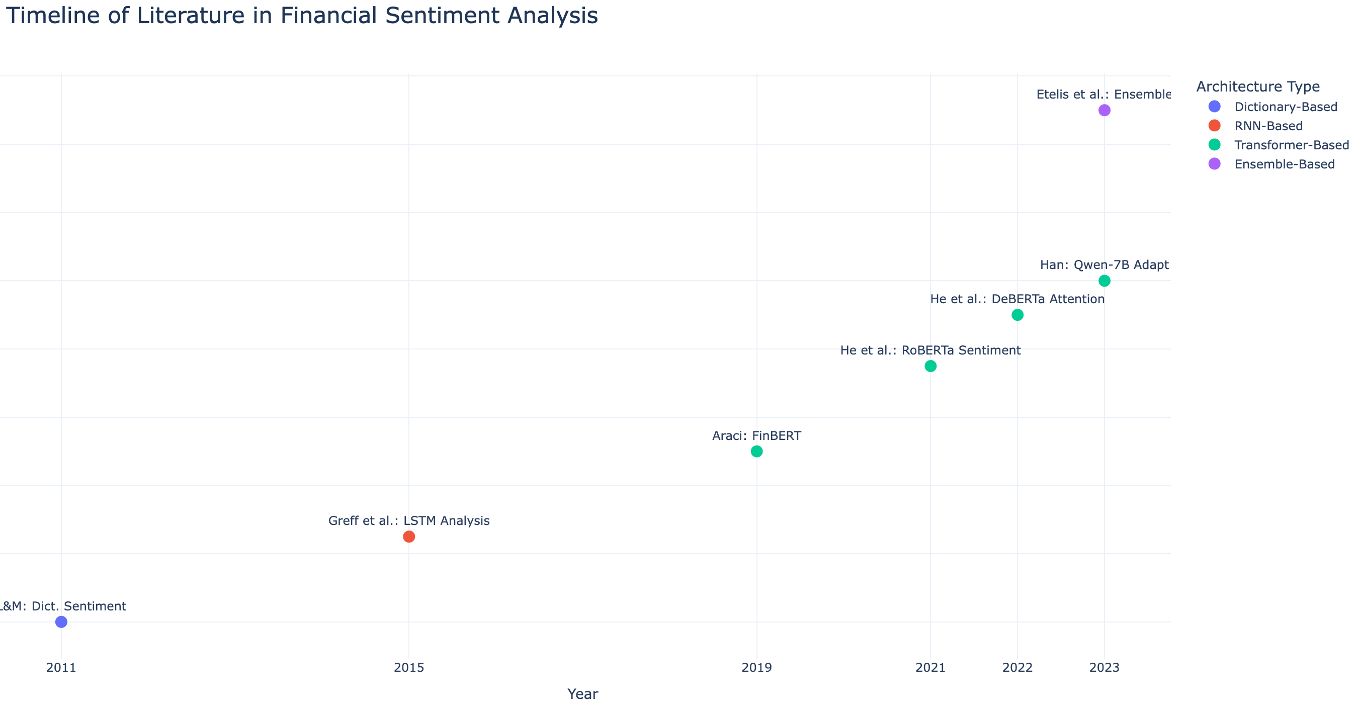

As delineated below, that the training process was broadly the same throughout, but as mentioned a two stage process was taken for the selection of better models, in this case RoBERTa-large-tuned and deBERTa. LSTM, was set as the foundational model, and the selection of transformer-based BERT models, does showcase substantial improvements.

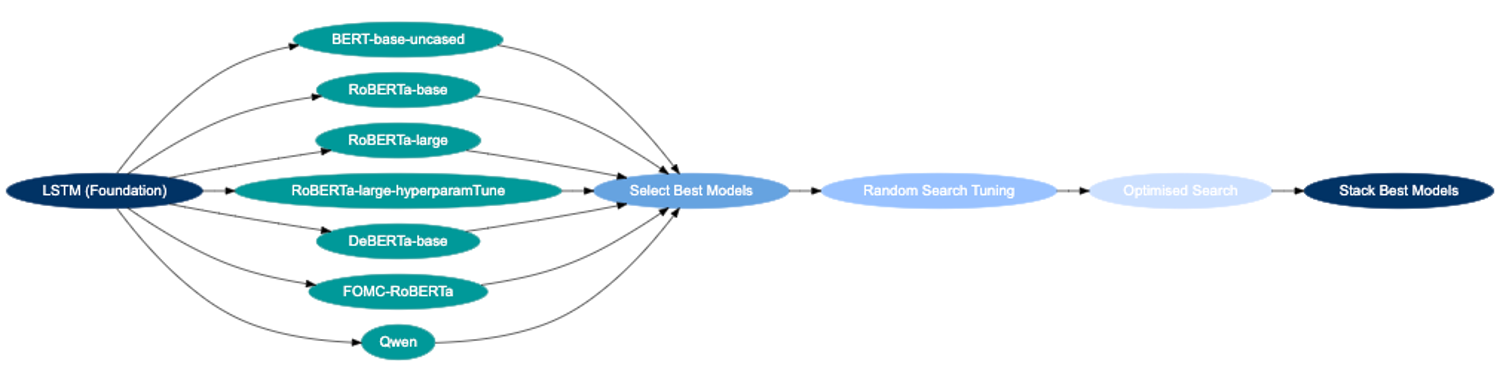







### 4.1 Hyperparamter Training Process

Originally, hyperparameters were initialised randomly to see overall performance. Then a selection of hyperparameters were chose, with the following rationale:


| Hyperparameter     | Why We Tuned It                                                                 | Impact on Model                                                                                  |
|--------------------|---------------------------------------------------------------------------------|--------------------------------------------------------------------------------------------------|
| **Learning Rate**  | Controls weight update magnitude; affects convergence speed and stability.     | Higher rate: Speeds up training but may overshoot the optimum. Lower rate: Stable but slower.    |
| **Batch Size**     | Number of samples processed before updating model parameters.                  | Larger batch: Stable gradients; requires more memory. Smaller batch: Better generalisation.    We capped this, as there was cuda memory issues  |
| **Epochs**         | Number of times the dataset is passed through the model.                      | More epochs: Improves pattern learning. Too many epochs: Risk of overfitting.                   |
| **Max Length**     | Maximum number of input tokens considered.  Ie. length of the sentences considered                   | Larger max length: Better context understanding; increases computation and memory usage. We capped this, as cuda ran out of memory constantly        |
| **Hidden Dropout** | Dropout in fully connected layers to prevent overfitting.                     | Higher dropout: Reduces overfitting; may slow convergence. Lower dropout: Risk of overfitting.  |
| **Attention Dropout** | Dropout in the attention mechanism for regularisation.                     | Moderate dropout: Promotes robustness. Too much dropout: Hinders learning important patterns.   |



**Random Search Process for deBERTa (as an example)**

| Trial | Learning Rate | Batch Size | Epochs | Max Length | Hidden Dropout | Attention Dropout | Test Accuracy | Test F1 Score |
|-------|---------------|------------|--------|------------|----------------|-------------------|---------------|---------------|
| 1     | 1.00E-05      | 8          | 3      | 128        | 0.1            | 0.1               | 0.514112903   | 0.475532808   |
| 2     | 3.00E-05      | 8          | 5      | 128        | 0.2            | 0.2               | 0.737903226   | 0.738384111   |
| 3     | 2.00E-05      | 8          | 5      | 256        | 0.2            | 0.1               | 0.747983871   | 0.748117281   |
| 4     | 1.00E-05      | 8          | 3      | 128        | 0.2            | 0.1               | 0.752016129   | 0.750811226   |
| 5     | 1.00E-05      | 8          | 5      | 256        | 0.2            | 0.1               | 0.737903226   | 0.737606474   |
| 6     | 1.00E-05      | 16         | 3      | 256        | 0.2            | 0.1               | 0.731854839   | 0.732716836   |
| 7     | 1.00E-05      | 16         | 3      | 128        | 0.1            | 0.2               | 0.719758065   | 0.718901159   |
| 8     | 3.00E-05      | 8          | 3      | 256        | 0.1            | 0.2               | 0.745967742   | 0.745317183   |
| 9     | 1.00E-05      | 8          | 3      | 256        | 0.1            | 0.1               | 0.741935484   | 0.741859184   |
| 10    | 2.00E-05      | 8          | 3      | 256        | 0.1            | 0.1               | 0.733870968   | 0.734802007   |


Random searches were run first to narrow down and then an optimisation process in a narrowed down range is run later. For example, in the above example of deBERTa with a patience of 2 epochs early stop was run. Note that this took 25 hours on an RTX3080, showcasing the computational expensiveness.

A random search was conducted for RoBERTa-large for 48 combinations, which took about a similar time to deBERTa, but later an optimisation process was run to develop better performance hyperparameters.




### 4.2 Overview of Models


| Index | Model Name                | Reference NoteBook               | Editor      |
|-------|---------------------------|----------------------------------|-------------|
| 1     | bert.pth                  | by_modeltest_bert_base.ipynb     | YingBi      |
| 2     | roberta-base.pth          | by_modeltest_roberta_base.ipynb  | YingBi      |
| 3     | roberta-large.pth         | by_modeltest_roberta_large.ipynb | YingBi      |
| 4     | roberta-large-yongpei.pth | lyp_modelest_roberta_large.ipynb | YongPei Li  |
| 5     | debert-base.pth           | lyp_modeltest_debert_base.ipynb  | YongPei Li  |
| 6     | lstm_model.pth            | zt_modeltest_LSTM.ipynb          | Tong Zhang  |
| 7     | fomc-roberta.pth          | lzh_modeltest_fomc_roberta.ipynb | ZhenHua Liu |
| 8     | Qwen2.5-3B-Instruct       | lzh_modeltest_qwen2.5.ipynb      | ZhenHua Liu |

The models below, were saved in 'pth' format, and we have unwrapped the model, and ru-run it side-by-side for evaluation purposes. Please note that the Qwen model was not saved in pth file, but we extracted the results still for evaluation purposes. It wasn't the best however, but is just another potential evaluation point.

In [52]:
models = {
    'lstm': './models/lstm_model.pth',    
    'bert-base-uncased': './models/bert.pth',
    'roberta-base': './models/roberta-base.pth',
    'roberta-large': './models/roberta-large.pth',
    'roberta-large-yongpei': './models/roberta-large-yongpei.pth',
    'debert-base': './models/debert-base.pth',
    'FOMC-RoBERTa': './models/fomc-roberta.pth',
}

## 5. Results
In this part, we compare all the models by using the same dataset and codes. Load the different pth models and compare the results in one table.

In [53]:
import pandas as pd
import numpy  as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import accuracy_score, f1_score, precision_score
from transformers import BertTokenizer, BertModel, RobertaTokenizer, RobertaModel, AutoTokenizer, AutoModel, BertForSequenceClassification, RobertaForSequenceClassification, AutoModelForSequenceClassification
import warnings
# Suppress specific warnings
warnings.filterwarnings("ignore", category=FutureWarning, module="transformers.tokenization_utils_base")
warnings.filterwarnings("ignore", category=UserWarning, module="torch.serialization")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
test_df = pd.read_excel('./ipynb_projects/dataset/lab-manual-split-combine-test-944601.xlsx')


In [55]:
class BertDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, index):
        text = self.texts[index]
        label = self.labels[index]
        
        # 编码文本
        encoding = self.tokenizer(
            text,
            padding='max_length',
            truncation=True,
            max_length=self.max_len,
            return_tensors='pt',
        )

        return {
            'input_ids': encoding['input_ids'].squeeze().to(device),
            'attention_mask': encoding['attention_mask'].squeeze().to(device),
            'labels': torch.tensor(label, dtype=torch.long).to(device)
        }
import torch.nn.functional as F
class LSTMClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, output_dim, n_layers, dropout):
        super(LSTMClassifier, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim)
        self.lstm = nn.LSTM(embed_dim, hidden_dim, n_layers, dropout=dropout, batch_first=True)
        self.fc1 = nn.Linear(hidden_dim, 128)
        self.fc2 = nn.Linear(128, output_dim)
        self.dropout = nn.Dropout(dropout)

    def forward(self, input_ids, attention_mask):
        embedded = self.embedding(input_ids)
        packed_output, (hidden, cell) = self.lstm(embedded)
        hidden = hidden[-1]
        x = self.dropout(F.relu(self.fc1(hidden)))
        output = self.fc2(x)
        return output

In [1]:
def load_model_and_tokenizer(model_name, model_path, num_labels):
    if model_name == "bert-base-uncased":
        tokenizer = BertTokenizer.from_pretrained(model_name)
        model = BertForSequenceClassification.from_pretrained(model_name, num_labels=num_labels)
    elif model_name == "roberta-base" or model_name == "roberta-large":
        tokenizer = RobertaTokenizer.from_pretrained(model_name)
        model = RobertaForSequenceClassification.from_pretrained(model_name, num_labels=num_labels)
    elif model_name == "roberta-large-yongpei":
        model_name = "roberta-large"
        tokenizer = RobertaTokenizer.from_pretrained(model_name)
        model = RobertaForSequenceClassification.from_pretrained(model_name, num_labels=num_labels)
    elif model_name == "debert-base":
        tokenizer = AutoTokenizer.from_pretrained("microsoft/deberta-base")
        model = AutoModelForSequenceClassification.from_pretrained("microsoft/deberta-base", num_labels=num_labels)
    elif model_name == "FOMC-RoBERTa":
        tokenizer = AutoTokenizer.from_pretrained("gtfintechlab/FOMC-RoBERTa")
        model = AutoModelForSequenceClassification.from_pretrained("gtfintechlab/FOMC-RoBERTa", num_labels=num_labels)
    elif model_name == "lstm":
        model = LSTMClassifier(vocab_size=30522, embed_dim=128, hidden_dim=256, output_dim=3, n_layers=2, dropout=0.3).to(device)
        model.load_state_dict(torch.load(model_path, map_location=device))
        tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
        return model, tokenizer
    else:
        raise ValueError(f"Unsupported model: {model_name}")

    state_dict = torch.load(model_path, map_location=device, weights_only=True)
    model.load_state_dict(state_dict, strict=False)
    model.to(device)
    model.eval()
    return model, tokenizer


def predict(model, test_loader):
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for batch in test_loader:
            input_ids = batch['input_ids']
            attention_mask = batch['attention_mask']
            labels = batch['labels']

            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            logits = outputs.logits
            preds = torch.argmax(logits, dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    accuracy = accuracy_score(all_labels, all_preds)
    f1 = f1_score(all_labels, all_preds, average='weighted')
    precision = precision_score(all_labels, all_preds, average='weighted')

    return accuracy, f1, precision


def predict_LSTM(model, device, test_loader, criterion):
    model.eval()
    test_loss = 0
    correct = 0
    all_preds = []
    all_labels = []
    with torch.no_grad():
        for batch in test_loader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)
            
            outputs = model(input_ids, attention_mask)
            test_loss += criterion(outputs, labels).item()
            pred = outputs.argmax(dim=1, keepdim=True)
            correct += pred.eq(labels.view_as(pred)).sum().item()
            all_preds.extend(pred.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    test_loss /= len(test_loader.dataset)
    accuracy = correct / len(test_loader.dataset)
    f1 = f1_score(all_labels, all_preds, average='weighted')
    precision = precision_score(all_labels, all_preds, average='weighted')
    return accuracy, f1, precision

In [57]:
import sys
import os
max_len = 150
num_labels = len(test_df['label'].unique())
results = {}
for model_name, model_path in models.items():
    # Redirect stdout to suppress print statements
    original_stdout = sys.stdout
    sys.stdout = open(os.devnull, 'w')
    try:
        model, tokenizer = load_model_and_tokenizer(model_name, model_path, num_labels)
        test_dataset = BertDataset(test_df['sentence'].tolist(), test_df['label'].values, tokenizer, max_len)
        test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)
        criterion = nn.CrossEntropyLoss()
        if model_name == "lstm":
            accuracy, f1, precision = predict_LSTM(model, device, test_loader, criterion)
        else:
            accuracy, f1, precision = predict(model, test_loader)
    finally:
        sys.stdout.close()
        sys.stdout = original_stdout

    results[model_name] = {
        'accuracy': accuracy,
        'f1': f1,
        'precision': precision
    }

/var/folders/jb/0yw0kvrd1_v71gfrz0qxs0m80000gn/T/ipykernel_11207/4270491704.py:20: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(model_path,

                      accuracy       f1 precision
lstm                   0.49798  0.33110   0.24799
bert-base-uncased      0.61895  0.61899   0.62178
roberta-base           0.67137  0.67402   0.67920
roberta-large          0.83065  0.83042   0.83132
roberta-large-yongpei  0.93347  0.93335   0.93366
debert-base            0.67742  0.67763   0.67784
FOMC-RoBERTa           0.71573  0.71870   0.73302


/var/folders/jb/0yw0kvrd1_v71gfrz0qxs0m80000gn/T/ipykernel_11207/1116304341.py:7: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df = df.applymap(lambda x: f"{x:.5f}")


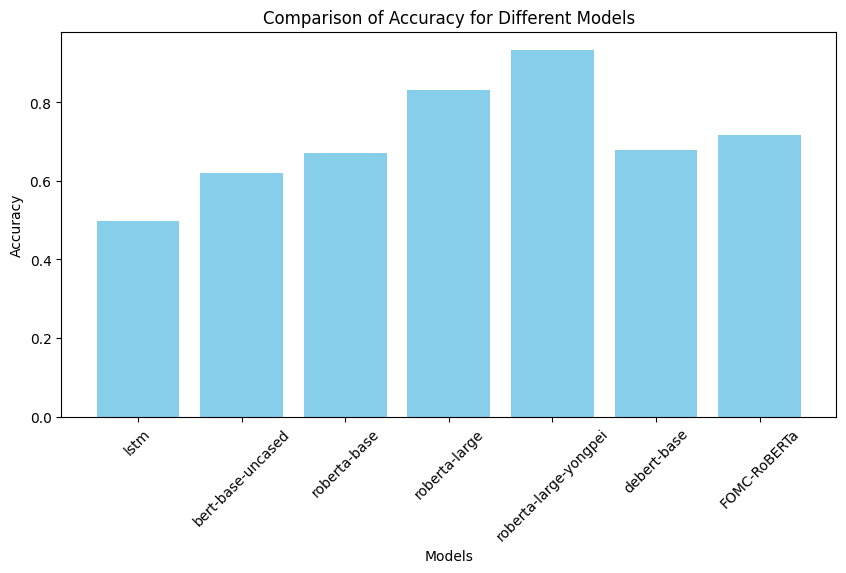

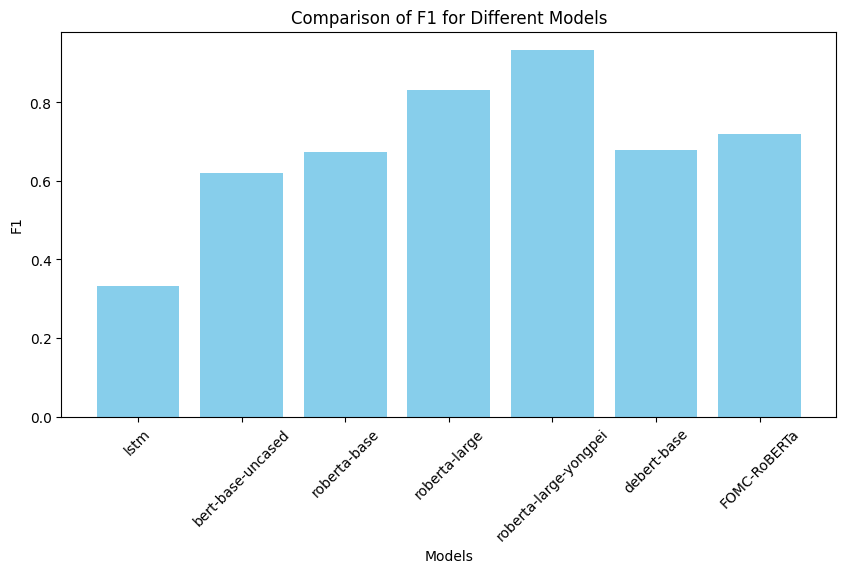

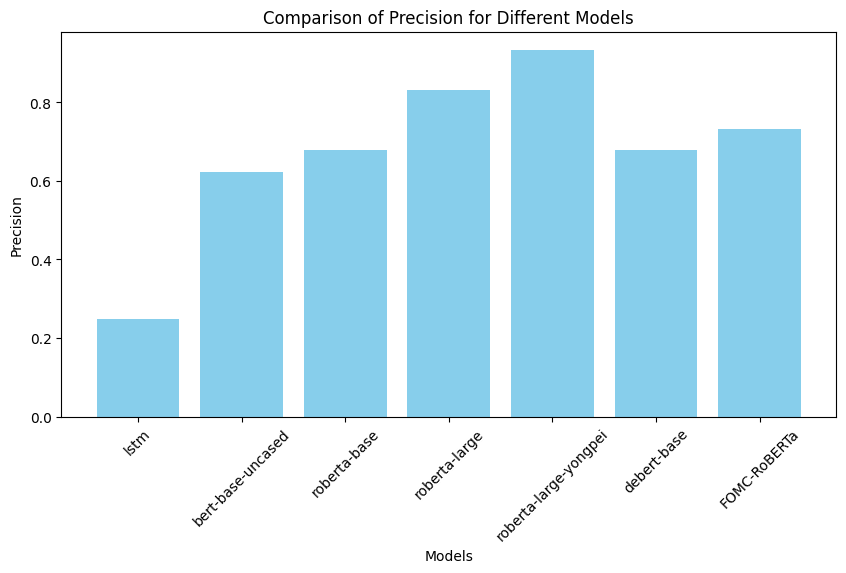

In [58]:
import pandas as pd
def display_results_table(results):
    # Convert the results dictionary to a pandas DataFrame
    df = pd.DataFrame(results).T
    
    # Format the values to 5 decimal places
    df = df.applymap(lambda x: f"{x:.5f}")
    
    # Display the DataFrame
    print(df)
    
display_results_table(results)

import matplotlib.pyplot as plt
def plot_metrics(results, metric):
    models = list(results.keys())
    values = [results[model][metric] for model in models]

    plt.figure(figsize=(10, 5))
    plt.bar(models, values, color='skyblue')
    plt.xlabel('Models')
    plt.ylabel(metric.capitalize())
    plt.title(f'Comparison of {metric.capitalize()} for Different Models')
    plt.xticks(rotation=45)
    plt.show()

# Plot accuracy
plot_metrics(results, 'accuracy')

# Plot F1 score
plot_metrics(results, 'f1')

# Plot precision
plot_metrics(results, 'precision')

- The results of Qwen2.5-3B get the results metrics: Accuracy: 69.0476190476%  F1 Score: 0.6927251355 Precision: 0.6976743011 

(Refer to the notebook for more details)

### 5.1.1: Comparison of all Models, across Accuracy, F1, Precision

As seen, all the transformer-baed models outperform the LSTM baseline, which does demonstrate the efficacies of such architectures for Sentiment Analysis.

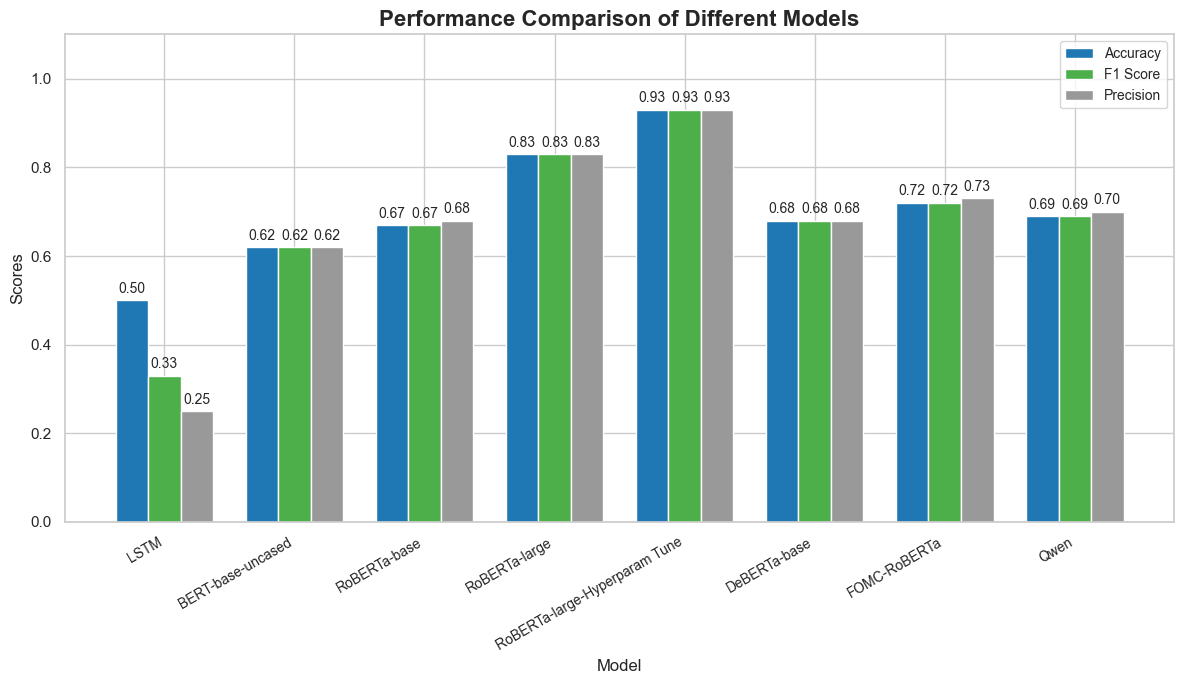

In [31]:
import matplotlib.pyplot as plt
import numpy as np

# Data
models = [
    'LSTM', 'BERT-base-uncased', 'RoBERTa-base', 'RoBERTa-large',
    'RoBERTa-large-Hyperparam Tune', 'DeBERTa-base', 'FOMC-RoBERTa', 'Qwen'
]
accuracy = [0.50, 0.62, 0.67, 0.83, 0.93, 0.68, 0.72, 0.69]
f1_score = [0.33, 0.62, 0.67, 0.83, 0.93, 0.68, 0.72, 0.69]
precision = [0.25, 0.62, 0.68, 0.83, 0.93, 0.68, 0.73, 0.70]

x = np.arange(len(models))
width = 0.25

fig, ax = plt.subplots(figsize=(12, 7))
bars1 = ax.bar(x - width, accuracy, width, label='Accuracy', color='#1f77b4')
bars2 = ax.bar(x, f1_score, width, label='F1 Score', color='#4daf4a')
bars3 = ax.bar(x + width, precision, width, label='Precision', color='#999999')

for bars in [bars1, bars2, bars3]:
    for bar in bars:
        yval = bar.get_height()
        ax.text(bar.get_x() + bar.get_width() / 2, yval + 0.01, f'{yval:.2f}', ha='center', va='bottom', fontsize=10)

ax.set_ylabel('Scores', fontsize=12)
ax.set_xlabel('Model', fontsize=12)
ax.set_title('Performance Comparison of Different Models', fontsize=16, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(models, rotation=30, ha='right', fontsize=10)
ax.set_ylim(0, 1.1)
ax.legend(fontsize=10)


for bar in bars1:
    if bar.get_x() == x[0] - width:
        bar.set_edgecolor('red')
        bar.set_linewidth(2)
        bar.set_linestyle('--')

    if bar.get_x() == x[4] - width:
        bar.set_edgecolor('green')
        bar.set_linewidth(2)
        bar.set_linestyle('--')

plt.tight_layout()
plt.show()


### 5.1 LIME (Local Interpretable Model-agnostic Explanations)

Set-up for RoBERTa-large LIME:

In [17]:
import torch
from transformers import RobertaTokenizer, RobertaForSequenceClassification

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

num_labels = 3

tokenizer = RobertaTokenizer.from_pretrained('roberta-large')

model = RobertaForSequenceClassification.from_pretrained('roberta-large', num_labels=num_labels)

model.load_state_dict(torch.load('roberta-large-yongpei.pth', map_location=device), strict=False)

model.to(device)
model.eval()


Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at roberta-large and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/var/folders/n5/9zhvmlhx1n567x390q9y8ml40000gn/T/ipykernel_25635/538461854.py:17: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded 

RobertaForSequenceClassification(
  (roberta): RobertaModel(
    (embeddings): RobertaEmbeddings(
      (word_embeddings): Embedding(50265, 1024, padding_idx=1)
      (position_embeddings): Embedding(514, 1024, padding_idx=1)
      (token_type_embeddings): Embedding(1, 1024)
      (LayerNorm): LayerNorm((1024,), eps=1e-05, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): RobertaEncoder(
      (layer): ModuleList(
        (0-23): 24 x RobertaLayer(
          (attention): RobertaAttention(
            (self): RobertaSdpaSelfAttention(
              (query): Linear(in_features=1024, out_features=1024, bias=True)
              (key): Linear(in_features=1024, out_features=1024, bias=True)
              (value): Linear(in_features=1024, out_features=1024, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): RobertaSelfOutput(
              (dense): Linear(in_features=1024, out_features=1024, bias=Tru

In [18]:
def lime_predict(texts):
    # Tokenize the sentences that we want to use
    inputs = tokenizer(texts, padding=True, truncation=True, max_length=75, return_tensors='pt')
    inputs = {k: v.to(device) for k, v in inputs.items()}
    
    with torch.no_grad():
        outputs = model(**inputs)
        logits = outputs.logits
        probabilities = torch.softmax(logits, dim=1).cpu().numpy()
    return probabilities


In [20]:
from lime.lime_text import LimeTextExplainer
from IPython.core.display import display, HTML

explainer = LimeTextExplainer(class_names=['Dovish', 'Hawkish', 'Neutral'])

sample_text = "Setting the horizon on the interest rate caps to reinforce forward guidance on the policy rate would augment the credibility of the yield curve caps and thereby diminish concerns about an open-ended balance sheet commitment."

exp = explainer.explain_instance(sample_text, lime_predict, num_features=10, num_samples=2000, top_labels=3)

html_explanation = exp.as_html()
display(HTML(html_explanation))

with open('LIME_Text_Explanation_RoBERTa-large.html', 'w') as file:
    file.write(html_explanation)


/var/folders/n5/9zhvmlhx1n567x390q9y8ml40000gn/T/ipykernel_25635/2987374073.py:2: DeprecationWarning: Importing display from IPython.core.display is deprecated since IPython 7.14, please import from IPython display
  from IPython.core.display import display, HTML


Set-up for the LSTM LIME.

In [24]:
import torch
import torch.nn as nn
from transformers import BertTokenizer
from lime.lime_text import LimeTextExplainer
from IPython.core.display import display, HTML

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')

class LSTMModel(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_dim, output_dim, n_layers=2, dropout_prob=0.3):
        super(LSTMModel, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim)
        self.lstm = nn.LSTM(embedding_dim, hidden_dim, n_layers, dropout=dropout_prob, batch_first=True)
        self.fc1 = nn.Linear(hidden_dim, 128)
        self.fc2 = nn.Linear(128, output_dim)
        self.dropout = nn.Dropout(dropout_prob)

    def forward(self, x):
        x = self.embedding(x)
        out, _ = self.lstm(x)
        out = out[:, -1, :]
        out = self.dropout(torch.relu(self.fc1(out)))
        out = self.fc2(out)
        return out

# As per the training, using the same hyperparams
vocab_size = tokenizer.vocab_size
embedding_dim = 128
hidden_size = 256
output_size = 3
n_layers = 2
dropout_prob = 0.3

lstm_model = LSTMModel(
    vocab_size=vocab_size,
    embedding_dim=embedding_dim,
    hidden_dim=hidden_size,
    output_dim=output_size,
    n_layers=n_layers,
    dropout_prob=dropout_prob
)
lstm_model.load_state_dict(torch.load('lstm_model.pth', map_location=device))
lstm_model.to(device)
lstm_model.eval()

def lime_predict(texts):
    max_length = 50
    inputs = tokenizer(texts, padding=True, truncation=True, max_length=max_length, return_tensors='pt')
    input_ids = inputs['input_ids'].to(device)
    with torch.no_grad():
        outputs = lstm_model(input_ids)
        probabilities = torch.softmax(outputs, dim=1).cpu().numpy()
    return probabilities

explainer = LimeTextExplainer(class_names=['Dovish', 'Hawkish', 'Neutral'])

sample_text = "Setting the horizon on the interest rate caps to reinforce forward guidance on the policy rate would augment the credibility of the yield curve caps and thereby diminish concerns about an open-ended balance sheet commitment."

exp = explainer.explain_instance(sample_text, lime_predict, num_features=10, num_samples=2000, top_labels=3)

html_explanation = exp.as_html()
display(HTML(html_explanation))
with open('LIME_Text_Explanation_LSTM.html', 'w') as file:
    file.write(html_explanation)


/var/folders/n5/9zhvmlhx1n567x390q9y8ml40000gn/T/ipykernel_25635/1313916840.py:5: DeprecationWarning: Importing display from IPython.core.display is deprecated since IPython 7.14, please import from IPython display
  from IPython.core.display import display, HTML
/var/folders/n5/9zhvmlhx1n567x390q9y8ml40000gn/T/ipykernel_25635/1313916840.py:48: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_saf

### 5.1.2 Commentary for LIME:

As shown in the comparisons between RoBERTa-large (first) and the LSTM (second), there are discernible differences in confidence in categorisation for both. For the same string, RoBERTa-large is far more confident in predicting the "netural", whereas LSTM really struggles. This does provide much more clarity into the structure, by looking at the relative predicted probability of how each word contributes to the sentiment categorisation at the end. In this case, RoBERTa will categorise it as "neural correctly, and the LSTM will categorise it as "Dovish", incorrectly. It may be interesting, if time was not a constraint, to look into samples of where RoBERTa predicted wrongly, and LSTM predicted correctly, for further investigative purposes.

### 5.2 Results Explanation
From the 8 models we have tested, here are our main findings:
- RoBERTa Large model shows a significant leap in performance compared to its base models and other models. After configuring different learning_rate, batch_size, epochs, max_len, hidden_dropout, its result suggests well-tuned and capability of handling the classification task.
- LSTM has the worst model performance among all the models evaluated. There are may be several reasonse. 1. LSTM is less complex compared with other transformer-based models to deal with the classification task. 2. LSTM may need more careful tuning to achieve better results. 3. LSTM rely on sequential processing, which may not understand the most relevant features.
- For the other models, they have quite similar results which means they have the capability of dealing with the classification task in the same level. Compared with LSTM, they have more significant advantage to understand the language patterns.


RoBERTa-large tuned, performed tbe best by far, as it was pretrained on significantly more data compared to other models like BERT, and can therefore capture more context dependencies. Other reasons like dynamic masking measn it can learn more robust word representations, and quite frankly - the increased model size (355Million), which is substantially more than other variants.

### 5.3 Stack Modeling
In this part, we do not use only one single model to make the predictions but also tried to stack two different models and hope to get a better performance. We make the predictions with different models and use those predictions as features for a higher-level meta model.
However, the stacking models can not achieve better results. We have analyzed that
- Weak model diversity. The based models are too similar, leading to correlated errors.
- Not enough training data size. The training data is not enough for the meta-model.

In [60]:
def predict_stack(model, test_loader):
    model.eval()
    all_preds = []

    with torch.no_grad():
        for batch in test_loader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)

            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            logits = outputs.logits
            preds = torch.argmax(logits, dim=1)

            all_preds.extend(preds.cpu().numpy())

    return np.array(all_preds)

def predict_LSTM_stack(model, test_loader):
    model.eval()
    all_preds = []

    with torch.no_grad():
        for batch in test_loader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)

            outputs = model(input_ids, attention_mask)
            preds = torch.argmax(outputs, dim=1)

            all_preds.extend(preds.cpu().numpy())

    return np.array(all_preds)

In [61]:
train_df = pd.read_excel('./ipynb_projects/dataset/lab-manual-split-combine-train-5768.xlsx')
test_df = pd.read_excel('./ipynb_projects/dataset/lab-manual-split-combine-test-5768.xlsx')
train_dataset = BertDataset(train_df['sentence'].tolist(), train_df['label'].values, tokenizer, max_len=128)
test_dataset = BertDataset(test_df['sentence'].tolist(), test_df['label'].values, tokenizer, max_len=128)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

def predict_stack(model, test_loader):
    model.eval()
    all_preds = []

    with torch.no_grad():
        for batch in test_loader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)

            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            logits = outputs.logits
            preds = torch.argmax(logits, dim=1)

            all_preds.extend(preds.cpu().numpy())

    return np.array(all_preds)

def predict_LSTM_stack(model, test_loader):
    model.eval()
    all_preds = []

    with torch.no_grad():
        for batch in test_loader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)

            outputs = model(input_ids, attention_mask)
            preds = torch.argmax(outputs, dim=1)

            all_preds.extend(preds.cpu().numpy())

    return np.array(all_preds)

num_labels = 3
models_stack = {
    'roberta-large-yongpei': './models/roberta-large-yongpei.pth',
    'debert-base': './models/debert-base.pth',
}

from sklearn.linear_model import LogisticRegression
# Generate predictions for the training set
train_predictions = []
for model_name, model_path in models_stack.items():
    model, tokenizer = load_model_and_tokenizer(model_name, model_path, num_labels)
    if model_name == "lstm":
        preds = predict_LSTM_stack(model, train_loader)
    else:
        preds = predict_stack(model, train_loader)
    train_predictions.append(preds)

# Generate predictions for the test set
test_predictions = []
for model_name, model_path in models_stack.items():
    model, tokenizer = load_model_and_tokenizer(model_name, model_path, num_labels)
    if model_name == "lstm":
        preds = predict_LSTM_stack(model, test_loader)
    else:
        preds = predict_stack(model, test_loader)
    test_predictions.append(preds)

# Stack predictions to create meta-dataset
train_meta_features = np.stack(train_predictions, axis=1)
test_meta_features = np.stack(test_predictions, axis=1)

# Train the meta-model
meta_model = LogisticRegression()
meta_model.fit(train_meta_features, train_df['label'])

# Evaluate the meta-model
meta_preds = meta_model.predict(test_meta_features)
accuracy = accuracy_score(test_df['label'], meta_preds)
f1 = f1_score(test_df['label'], meta_preds, average='weighted')
precision = precision_score(test_df['label'], meta_preds, average='weighted')

print(f"Meta-model Accuracy: {accuracy}")
print(f"Meta-model F1 Score: {f1}")
print(f"Meta-model Precision: {precision}")

Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at roberta-large and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Some weights of DebertaForSequenceClassification were not initialized from the model checkpoint at microsoft/deberta-base and are newly initialized: ['classifier.bias', 'classifier.weight', 'pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at roberta-large and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a 

Meta-model Accuracy: 0.4939516129032258
Meta-model F1 Score: 0.32663466980105355
Meta-model Precision: 0.24398819588969822


/Users/zhangtong/anaconda3/envs/nlp-9444/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


As shown, the meta-model, or the stacked model, does not perform. We suspect this is potentially a result of the similar architectures.

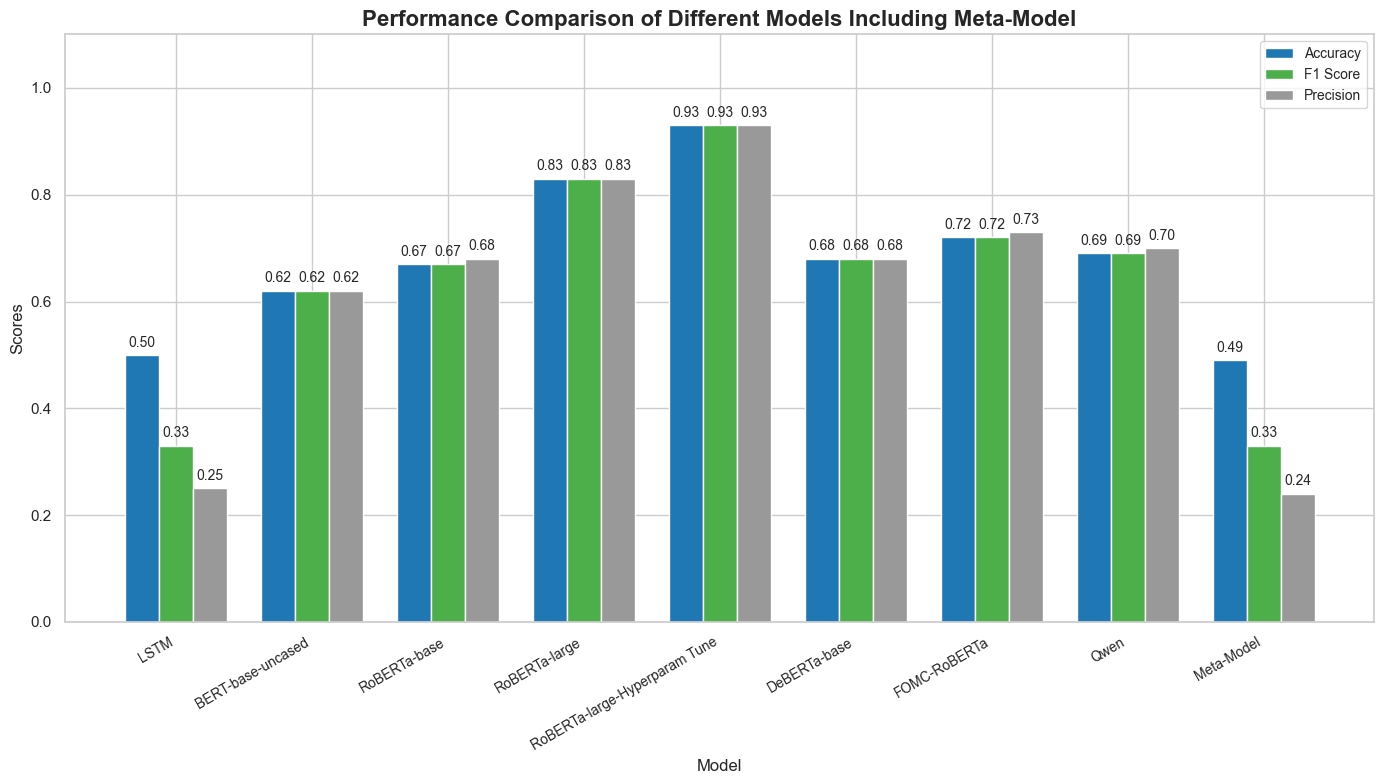

In [34]:
import matplotlib.pyplot as plt
import numpy as np

models = [
    'LSTM', 'BERT-base-uncased', 'RoBERTa-base', 'RoBERTa-large',
    'RoBERTa-large-Hyperparam Tune', 'DeBERTa-base', 'FOMC-RoBERTa', 'Qwen', 'Meta-Model'
]
accuracy = [0.50, 0.62, 0.67, 0.83, 0.93, 0.68, 0.72, 0.69, 0.49]
f1_score = [0.33, 0.62, 0.67, 0.83, 0.93, 0.68, 0.72, 0.69, 0.33]
precision = [0.25, 0.62, 0.68, 0.83, 0.93, 0.68, 0.73, 0.70, 0.24]

x = np.arange(len(models))
width = 0.25

fig, ax = plt.subplots(figsize=(14, 8))

bars1 = ax.bar(x - width, accuracy, width, label='Accuracy', color='#1f77b4')
bars2 = ax.bar(x, f1_score, width, label='F1 Score', color='#4daf4a')
bars3 = ax.bar(x + width, precision, width, label='Precision', color='#999999')

for bars in [bars1, bars2, bars3]:
    for bar in bars:
        yval = bar.get_height()
        ax.text(bar.get_x() + bar.get_width() / 2, yval + 0.01, f'{yval:.2f}', ha='center', va='bottom', fontsize=10)

ax.set_ylabel('Scores', fontsize=12)
ax.set_xlabel('Model', fontsize=12)
ax.set_title('Performance Comparison of Different Models Including Meta-Model', fontsize=16, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(models, rotation=30, ha='right', fontsize=10)
ax.set_ylim(0, 1.1)
ax.legend(fontsize=10)

for bar in bars1:
    if bar.get_x() == x[0] - width:
        bar.set_edgecolor('red')
        bar.set_linewidth(2)
        bar.set_linestyle('--')
    elif bar.get_x() == x[4] - width:
        bar.set_edgecolor('green')
        bar.set_linewidth(2)
        bar.set_linestyle('--')
    elif bar.get_x() == x[8] - width:
        bar.set_edgecolor('purple')
        bar.set_linewidth(2)
        bar.set_linestyle('--')

plt.tight_layout()
plt.show()


Refer to the RHS, showing the performance of the meta-model. It objectively peforms poorly, even worse than the LSTM. 

### 5.4 Confusion Matrix for Best Model

As we can see, based off the confusion matrix, the fine-tuned roberta-large model performs extremely well for FOMC sentiment analysis.

Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at roberta-large and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/var/folders/n5/9zhvmlhx1n567x390q9y8ml40000gn/T/ipykernel_25635/1221580671.py:18: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded

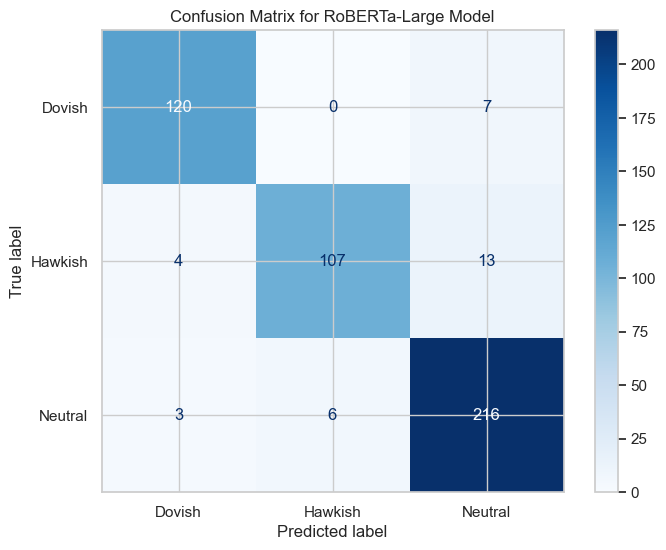

In [33]:
import pandas as pd
import torch
import numpy as np
from transformers import RobertaTokenizer, RobertaForSequenceClassification
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader

test_df = pd.read_excel('./dataset/lab-manual-combine-test-5768.xlsx')

# Set the device for model inference
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
num_labels = 3  # Dovish, Hawkish, Neutral

# Tokenizer and the model 
tokenizer = RobertaTokenizer.from_pretrained('roberta-large')
model = RobertaForSequenceClassification.from_pretrained('roberta-large', num_labels=num_labels)

model.load_state_dict(torch.load('./models/roberta-large-yongpei.pth', map_location=device), strict=False)
model.to(device)
model.eval()

class BertDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, index):
        text = self.texts[index]
        label = self.labels[index]
        
        encoding = self.tokenizer(
            text,
            padding='max_length',
            truncation=True,
            max_length=self.max_len,
            return_tensors='pt'
        )

        return {
            'input_ids': encoding['input_ids'].squeeze(),
            'attention_mask': encoding['attention_mask'].squeeze(),
            'labels': torch.tensor(label, dtype=torch.long)
        }

max_len = 75

test_dataset = BertDataset(test_df['sentence'].tolist(), test_df['label'].values, tokenizer, max_len)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

# Function to predict labels (for our cofnusion matrix)
def predict_roberta(model, test_loader):
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for batch in test_loader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].cpu().numpy()

            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            logits = outputs.logits
            preds = torch.argmax(logits, dim=1).cpu().numpy()

            all_preds.extend(preds)
            all_labels.extend(labels)

    return np.array(all_preds), np.array(all_labels)

preds, labels = predict_roberta(model, test_loader)
cm = confusion_matrix(labels, preds, labels=[0, 1, 2])
class_names = ['Dovish', 'Hawkish', 'Neutral']

# Plot confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(ax=ax, cmap=plt.cm.Blues)
plt.title("Confusion Matrix for RoBERTa-Large Model")
plt.show()


From the above Confusion Matrix, we can see that RoBERTa-large performs extremely well, with most proportionate confusions for the Hawkish. We would suspect once again, this is likely because of the idea of nuanced language - whereas its sucess in neutral does make sense, as it is the relatively dominant class, but also the nature of governmental publication is indeed neutral. 

## 6. Discussion

The experimental results of the project articulates the significant advancements of transfomer-based models within the context of financial sentiment analysis, especially for FOMC data. Our fine-tune RoBERTa-Large model emerged as the most effective by far, with 93% accuracy, F1, and precision. This not only doubles the baseline LSTM performance, but outperformed other models by substantial margins. It certainly also narrows the gap with state-of-the-art industry technology, such as Wellington Management's Quantiative Invesment Group (QIG) with an accuracy rate of about 97% that uses GPT-4o API. Note that this was based on personal conversations with Julia Klevak, a Research Scientist at Wellington, as one of our team members work there. As shown below, our model does almost reach what is currently used in industry. Although there is about ~ 4% gap, our experimentation does showcase a closed gap between literature and industrial practice.

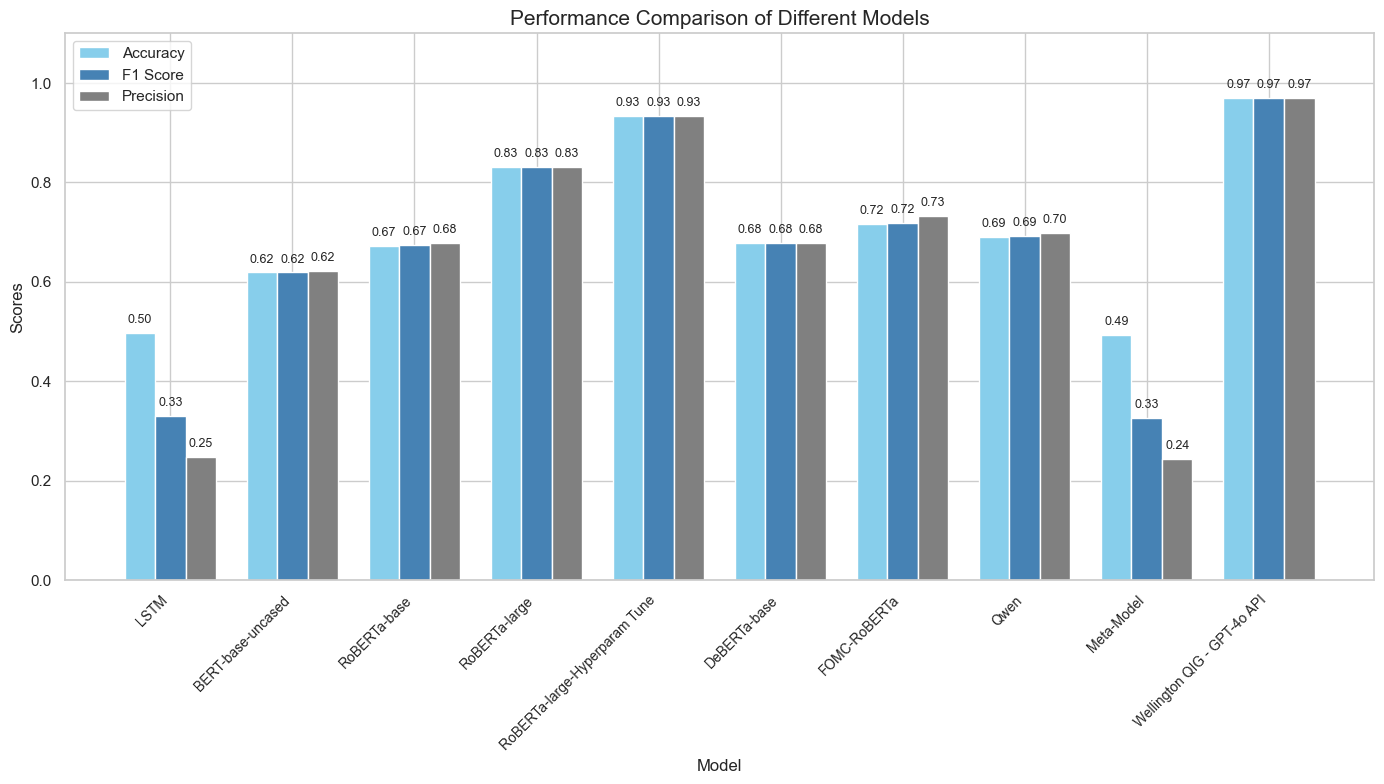

In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Data for model performance (again)
data = {
    "Model": ["LSTM", "BERT-base-uncased", "RoBERTa-base", "RoBERTa-large", 
              "RoBERTa-large-Hyperparam Tune", "DeBERTa-base", "FOMC-RoBERTa", 
              "Qwen", "Meta-Model", "Wellington QIG - GPT-4o API"],
    "Accuracy": [0.49798, 0.61895, 0.67137, 0.83065, 0.93347, 0.67742, 0.71573, 0.69048, 0.49395, 0.97],
    "F1 Score": [0.33110, 0.61899, 0.67402, 0.83042, 0.93335, 0.67763, 0.71870, 0.69273, 0.32663, 0.97],
    "Precision": [0.24799, 0.62178, 0.67920, 0.83132, 0.93366, 0.67784, 0.73302, 0.69767, 0.24399, 0.97]
}
df = pd.DataFrame(data)

plt.figure(figsize=(14, 8))
bar_width = 0.25
index = np.arange(len(df))
plt.bar(index - bar_width, df["Accuracy"], bar_width, label="Accuracy", color='skyblue')
plt.bar(index, df["F1 Score"], bar_width, label="F1 Score", color='steelblue')
plt.bar(index + bar_width, df["Precision"], bar_width, label="Precision", color='grey')

for idx, (acc, f1, prec) in enumerate(zip(df["Accuracy"], df["F1 Score"], df["Precision"])):
    plt.text(index[idx] - bar_width, acc + 0.02, f'{acc:.2f}', ha='center', fontsize=9)
    plt.text(index[idx], f1 + 0.02, f'{f1:.2f}', ha='center', fontsize=9)
    plt.text(index[idx] + bar_width, prec + 0.02, f'{prec:.2f}', ha='center', fontsize=9)

plt.xlabel('Model', fontsize=12)
plt.ylabel('Scores', fontsize=12)
plt.title('Performance Comparison of Different Models', fontsize=15)
plt.xticks(index, df["Model"], rotation=45, ha='right', fontsize=10)
plt.ylim(0, 1.1)
plt.legend()
plt.tight_layout()

plt.show()




Notable strengths of the current approach, includes especially the use of transfoemr architectures, especially with the RoBERTa-large model, with its ability to capture complex linguistic patterns and contextual nuances. In surpassing performance in Araci (2019) with the proposal of the finBERT that has ~85% accuracy, this was an amazing feat. 
In addition the two-stage hyperparameter tuning process, with an intiail random search was an instrumental approach in enhancing model performance, enabling efficient exploration of hyperparameter space in consideration of computational constraints. Our inclusion of a LIME, offers more transparency to our model's predictions. The more ambiguous responses of LSTM models, compared with more certainty provided by RoBERT-a large, does illustrate and account for the differences in performance. Consider the below example: 

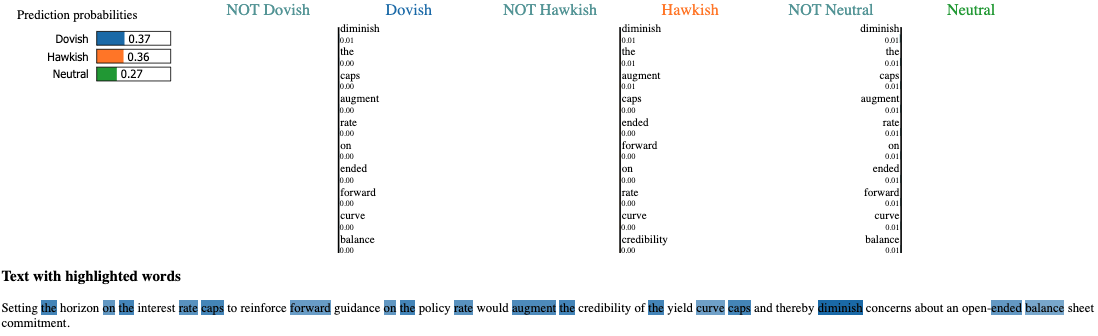

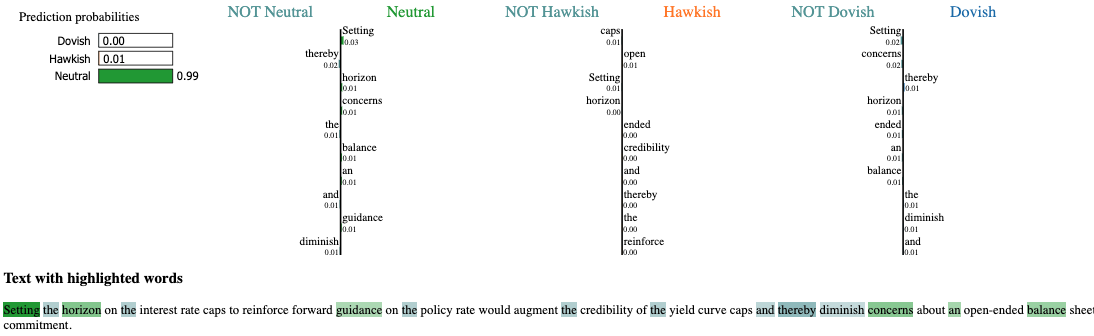

As we can see, the first LIME for LSTM shows far more uncertainty with it predicting "Dovish" for an objectively neutral statement, whereas RoBERTa-large shows far more certainty in predicting a "Neutral". 

The weaknesses of our approach was the idea of model stacking. Contrary to our expectations based on literature, our attempt at model stacking did not yield improvements and, in fact, resulted in performance degradation below 50% across evaluation metrics. This outcome, we believe stems from the common architecture in the base models (RoBERTa-large, DeBERTa), which magnified the areas, while limited areas to complement each other, as RoBERTa had already attained extremely high performance. This lack of diveristy amongst the base models can explain the limited ability to leverage complementary strengths.

Building on top of this, was the notion of high computational demands. For example in the case of hyperparameter tuning, for DeBERTa, the model required approximately  25 hours on an RTX 3080 GPU for only 10 combinations. These constraints severely limiteed the scope of exploration and certainly prevented even higher performance.


Overall, our experiments have indicated that transformer-based models significantly outperform traditional LSTM models in classifying FOMC sentiments, especally after fine-tuning in capturing the subtle differences between Hawkish, Dovish, and Neutral sentiments in FOMC texts. On the other hand, the underwhelming approach of stacking suggests that combining models may not necessarily lead to better outcomes, but might even worsen outcomes if not done correctly. Diversity in ensemble methods may have been helpful, especially ones with different underly architectures.

In addressing the limitations we encounteed to build upon this success, and narrow the gap between our study and industry, and maybe even one day surpass industry, there are a few more consideration like:

1) Incorporating Diverse Architectures, like Bloom or GPT-3 for stacking, so that diversity in an ensemble can mean that we improve the effectiveness of model stacking. Potentail for trying different pre-trained models specific to financial or economic texts to enhance the classification accuracy, and therefore improve its ability to generalise.

2) Potential for Knowledge Distillation, referring to the idea of knowledge transfer from computationally expensive models to smaller, more efficient ones that have similar performance. This ensures a balance between performance and computational feasibility, making it more practical, and can enable stacking of more base models.

3) Class Imbalance issue, whilst some studies have indicated it may not matter, it may be beneficial to consider other potential methods to account for the imbalance.




## Conclusion


Our project demonstrates that with careful model selection, fine-tuning, and optimisation, it is possible to significantly improve sentiment analysis of complex financial texts. The fine-tuned RoBERTa-large model's strong performance does showcase the potential for integration into industry workflows, where the **"best practice"** we deduced is a fine-tuned BERT model. Although challenges do certainly remain, especially noting computational demands and its relative returns, along with the demonstrated limitations of model stacking, our work solidifies and furthers the current foundation for further effots aimed at financial sentiment analyiss. In addressing the weaknesses we have noted, and potentially pursuing the three points of future work, there is boundless potnetial for greater advancement, enabling such models to support the Financial Services industry, in both superior performance and practicality.